# 04 — Departure SHAP Analysis (V9.0)

**Three-model SHAP comparison: LGB vs XGB vs CatBoost (23 features)**

Loads baseline models from NB03 context.

## 1. Setup & Load from NB03

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, shap, pickle
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('../../..')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ctx = pickle.load(open(DATA_PROCESSED / 'dep_baseline_context.pkl', 'rb'))
feature_columns = ctx['feature_columns']
X_train = ctx['X_train'].copy()
X_test = ctx['X_test'].copy()
y_train = ctx['y_train'].copy()
y_test = ctx['y_test'].copy()

# Load baseline models from NB03
lgb_model = ctx['lgb_model']
xgb_model = ctx['xgb_model']
cat_model = ctx['cb_model']

print(f'Loaded: {len(feature_columns)} features, {len(X_train):,} train, {len(X_test):,} test')
print(f'LGB AUC: {ctx["lgb_auc"]:.4f}, XGB AUC: {ctx["xgb_auc"]:.4f}, CatBoost AUC: {ctx["cb_auc"]:.4f}')


Loaded: 23 features, 104,460 train, 44,117 test
LGB AUC: 0.8808, XGB AUC: 0.8801, CatBoost AUC: 0.8868


## 2. Compute SHAP (3 models)

In [2]:
n_shap = min(5000, len(X_test))
X_shap = X_test.iloc[:n_shap]

lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap_values = lgb_explainer.shap_values(X_shap)
if isinstance(lgb_shap_values, list):
    lgb_shap_values = lgb_shap_values[1]
print(f'LGB SHAP: {lgb_shap_values.shape}')

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_shap)
if isinstance(xgb_shap_values, list):
    xgb_shap_values = xgb_shap_values[1]
print(f'XGB SHAP: {xgb_shap_values.shape}')

cat_explainer = shap.TreeExplainer(cat_model)
cat_shap_values = cat_explainer.shap_values(X_shap)
if isinstance(cat_shap_values, list):
    cat_shap_values = cat_shap_values[1]
print(f'CatBoost SHAP: {cat_shap_values.shape}')


LGB SHAP: (5000, 23)
XGB SHAP: (5000, 23)
CatBoost SHAP: (5000, 23)


## 3. Global Feature Importance (三模型对比)

Feature Importance (mean |SHAP|):
                 Feature    LGB    XGB  CatBoost    Avg
      prev_inbound_delay 1.3693 1.5452    1.8240 1.5795
        turnaround_hours 0.3401 0.3967    0.3697 0.3689
                    Hour 0.1829 0.2245    0.2546 0.2207
        route_risk_score 0.1227 0.1469    0.1399 0.1365
     dep_gate_delay_rate 0.1467 0.1342    0.1017 0.1276
        delay_rolling_3h 0.1225 0.1244    0.1312 0.1260
                   Month 0.1222 0.1325    0.1201 0.1249
           delay_rate_1h 0.1074 0.1059    0.1387 0.1173
  dep_airline_delay_rate 0.0925 0.0983    0.1480 0.1129
 severe_delay_count_prev 0.0778 0.0908    0.1059 0.0915
       terminal_delay_1h 0.0649 0.0756    0.1004 0.0803
        lga_arr_delay_1h 0.0562 0.0792    0.1034 0.0796
          dest_wx_impact 0.0676 0.0758    0.0834 0.0756
   dest_historical_delay 0.0774 0.0814    0.0605 0.0731
dep_runway_config_change 0.0417 0.0462    0.0485 0.0454
           dest_dewpoint 0.0292 0.0499    0.0300 0.0364
   dep_runway_

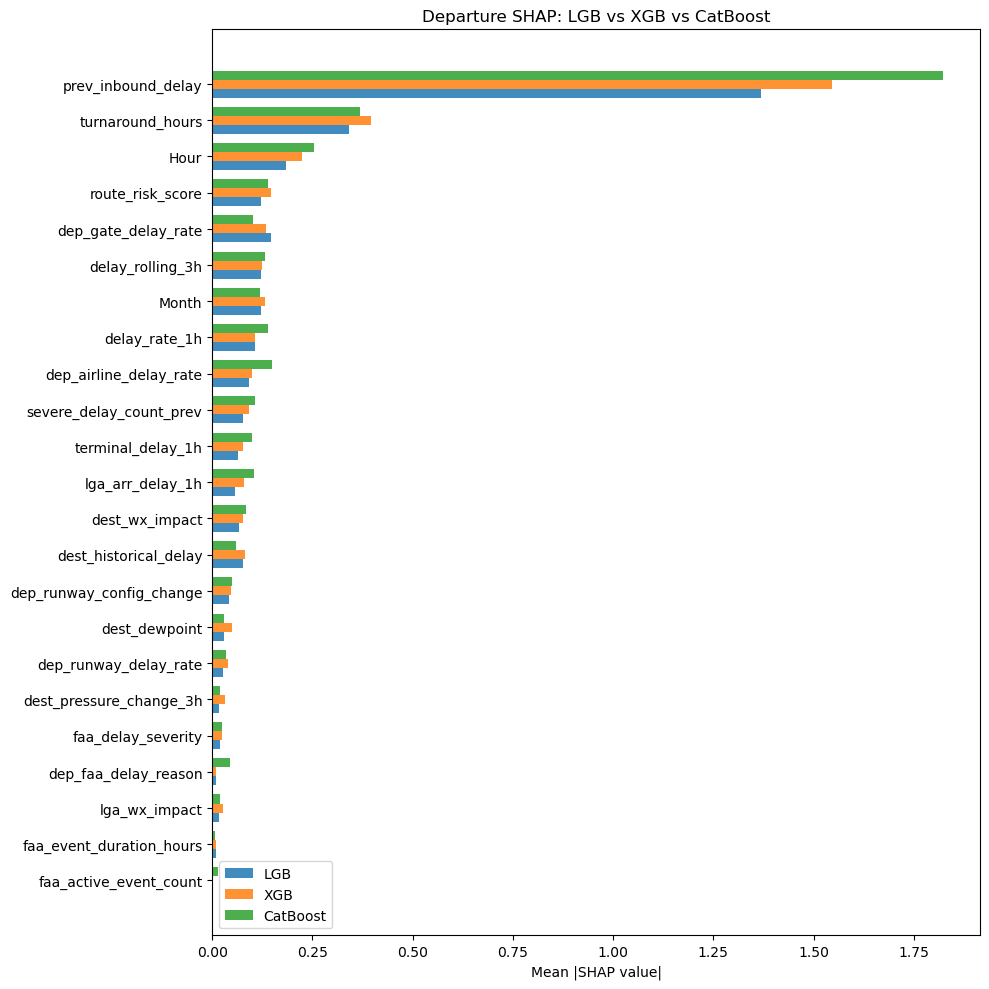

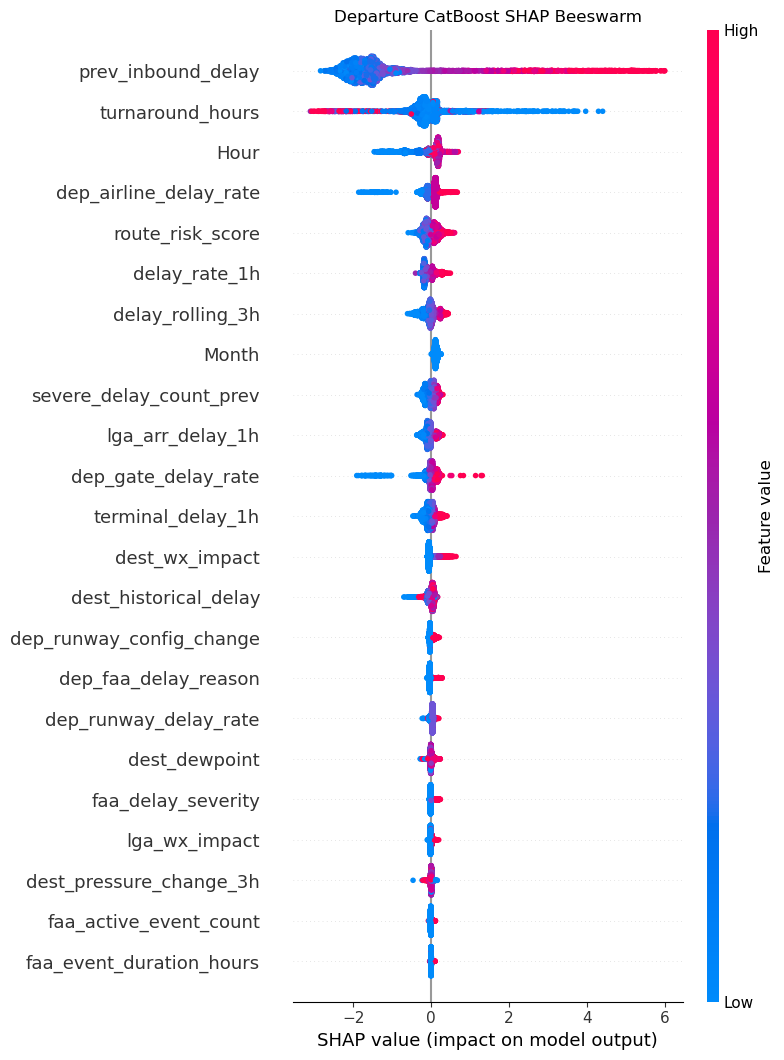

In [3]:
lgb_importance = np.abs(lgb_shap_values).mean(axis=0)
xgb_importance = np.abs(xgb_shap_values).mean(axis=0)
cat_importance = np.abs(cat_shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'LGB': lgb_importance, 'XGB': xgb_importance, 'CatBoost': cat_importance,
})
importance_df['Avg'] = importance_df[['LGB', 'XGB', 'CatBoost']].mean(axis=1)
importance_df = importance_df.sort_values('Avg', ascending=True)

print("Feature Importance (mean |SHAP|):")
print(importance_df.sort_values('Avg', ascending=False).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 10))
y = np.arange(len(feature_columns))
w = 0.25
ax.barh(y - w, importance_df['LGB'].values, w, label='LGB', alpha=0.85)
ax.barh(y, importance_df['XGB'].values, w, label='XGB', alpha=0.85)
ax.barh(y + w, importance_df['CatBoost'].values, w, label='CatBoost', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(importance_df['Feature'].values)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Departure SHAP: LGB vs XGB vs CatBoost')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dep_shap_bar_3model.png', dpi=150, bbox_inches='tight')
plt.show()

shap.summary_plot(cat_shap_values, X_shap, show=False, max_display=23)
plt.title('Departure CatBoost SHAP Beeswarm')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dep_shap_beeswarm_catboost.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Feature Category Analysis

In [4]:
categories = {
    'Core Lag': ['delay_rate_1h', 'delay_rolling_3h', 'severe_delay_count_prev', 'terminal_delay_1h'],
    'Cross-Direction': ['lga_arr_delay_1h'],
    'Aircraft': ['prev_inbound_delay', 'turnaround_hours'],
    'Target Encoding': ['dep_gate_delay_rate', 'dep_airline_delay_rate', 'dep_runway_delay_rate', 'dep_faa_delay_reason'],
    'Time': ['Hour', 'Month'],
    'Operational': ['faa_delay_severity', 'dep_runway_config_change'],
    'Dest Weather': ['dest_dewpoint', 'dest_pressure_change_3h', 'dest_historical_delay', 'dest_wx_impact'],
    'LGA Weather': ['lga_wx_impact'],
    'V9.0 New': ['faa_event_duration_hours', 'faa_active_event_count'],
    'Network': ['route_risk_score'],
}

for model_name, imp in [('LGB', lgb_importance), ('XGB', xgb_importance), ('CatBoost', cat_importance)]:
    print(f'\n--- {model_name} Category Contributions ---')
    total = imp.sum()
    for cat, feats in categories.items():
        avail = [f for f in feats if f in feature_columns]
        cat_sum = sum(imp[feature_columns.index(f)] for f in avail)
        print(f'  {cat:20s}: {cat_sum:.4f} ({cat_sum/total*100:.1f}%)')



--- LGB Category Contributions ---
  Core Lag            : 0.3726 (11.9%)
  Cross-Direction     : 0.0562 (1.8%)
  Aircraft            : 1.7095 (54.8%)
  Target Encoding     : 0.2756 (8.8%)
  Time                : 0.3051 (9.8%)
  Operational         : 0.0616 (2.0%)
  Dest Weather        : 0.1917 (6.1%)
  LGA Weather         : 0.0178 (0.6%)
  V9.0 New            : 0.0094 (0.3%)
  Network             : 0.1227 (3.9%)

--- XGB Category Contributions ---
  Core Lag            : 0.3968 (11.2%)
  Cross-Direction     : 0.0792 (2.2%)
  Aircraft            : 1.9419 (54.7%)
  Target Encoding     : 0.2809 (7.9%)
  Time                : 0.3569 (10.1%)
  Operational         : 0.0704 (2.0%)
  Dest Weather        : 0.2397 (6.8%)
  LGA Weather         : 0.0262 (0.7%)
  V9.0 New            : 0.0097 (0.3%)
  Network             : 0.1469 (4.1%)

--- CatBoost Category Contributions ---
  Core Lag            : 0.4762 (12.1%)
  Cross-Direction     : 0.1034 (2.6%)
  Aircraft            : 2.1937 (55.9%)
  Targ

## 5. V9.0 New Features Validation

V9.0 New Features SHAP:
  lga_wx_impact: LGB=0.0178, XGB=0.0262, CB=0.0192
  faa_event_duration_hours: LGB=0.0089, XGB=0.0082, CB=0.0069
  faa_active_event_count: LGB=0.0005, XGB=0.0015, CB=0.0145
  route_risk_score: LGB=0.1227, XGB=0.1469, CB=0.1399


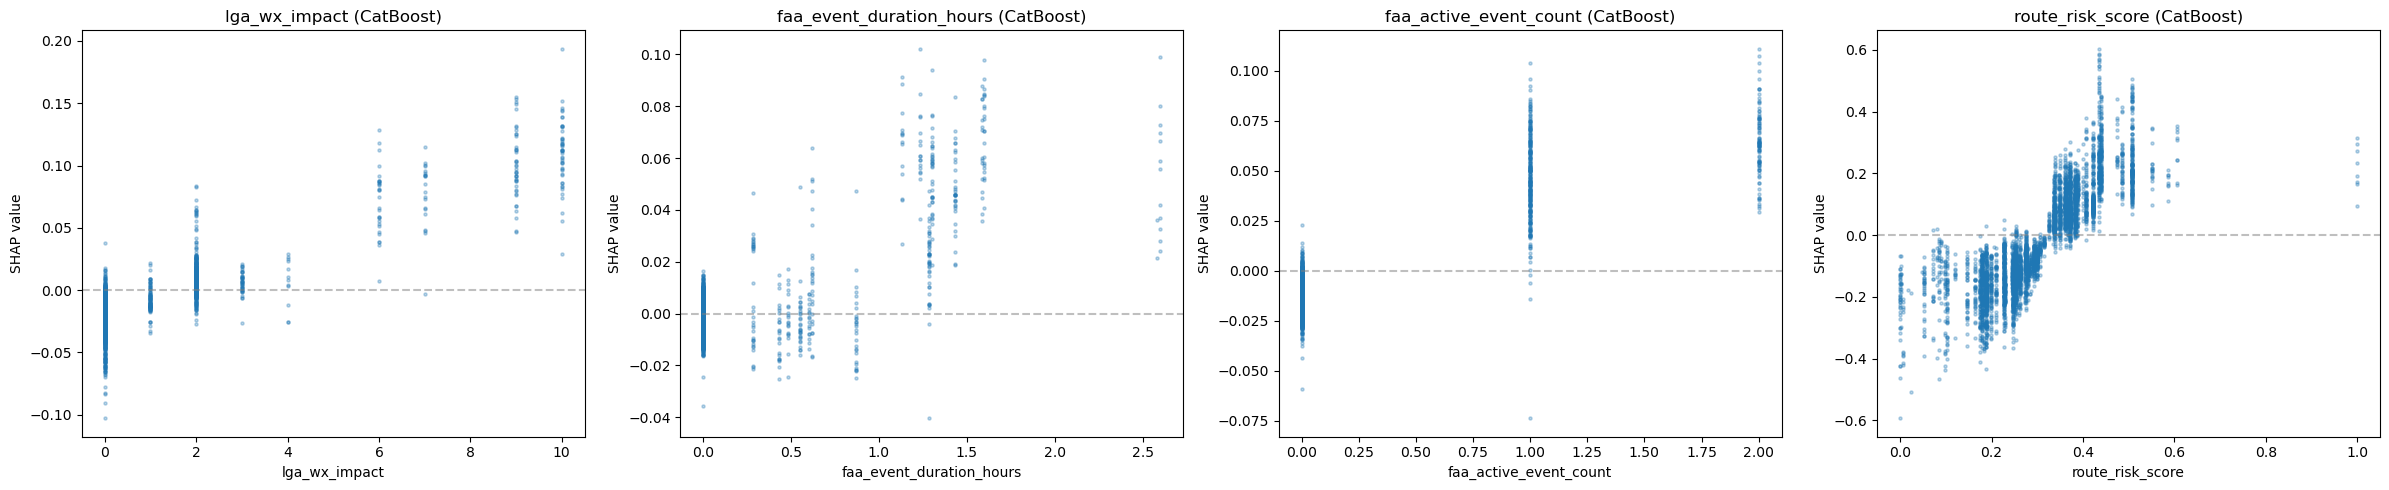

In [5]:
v9_features = ['lga_wx_impact', 'faa_event_duration_hours', 'faa_active_event_count', 'route_risk_score']
print("V9.0 New Features SHAP:")
for f in v9_features:
    if f in feature_columns:
        idx = feature_columns.index(f)
        print(f'  {f}: LGB={lgb_importance[idx]:.4f}, XGB={xgb_importance[idx]:.4f}, CB={cat_importance[idx]:.4f}')

fig, axes = plt.subplots(1, len(v9_features), figsize=(6*len(v9_features), 5))
if len(v9_features) == 1: axes = [axes]
for ax, feat in zip(axes, v9_features):
    if feat in feature_columns:
        idx = feature_columns.index(feat)
        ax.scatter(X_shap[feat], cat_shap_values[:, idx], alpha=0.3, s=5)
        ax.set_xlabel(feat); ax.set_ylabel('SHAP value')
        ax.set_title(f'{feat} (CatBoost)'); ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dep_shap_v9_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Cross-Model SHAP Ranking

In [6]:
ranking_df = pd.DataFrame({
    'Feature': feature_columns,
    'LGB_SHAP': lgb_importance, 'LGB_Rank': lgb_importance.argsort()[::-1].argsort() + 1,
    'XGB_SHAP': xgb_importance, 'XGB_Rank': xgb_importance.argsort()[::-1].argsort() + 1,
    'CB_SHAP': cat_importance, 'CB_Rank': cat_importance.argsort()[::-1].argsort() + 1,
})
ranking_df = ranking_df.sort_values('CB_Rank')
print("Cross-Model SHAP Ranking:")
print(ranking_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

ranking_df['Max_Diff'] = ranking_df[['LGB_Rank', 'XGB_Rank', 'CB_Rank']].apply(lambda r: r.max() - r.min(), axis=1)
divergent = ranking_df[ranking_df['Max_Diff'] > 5]
if len(divergent) > 0:
    print(f'\nDivergent features (rank diff > 5):')
    print(divergent[['Feature', 'LGB_Rank', 'XGB_Rank', 'CB_Rank', 'Max_Diff']].to_string(index=False))


Cross-Model SHAP Ranking:
                 Feature  LGB_SHAP  LGB_Rank  XGB_SHAP  XGB_Rank  CB_SHAP  CB_Rank
      prev_inbound_delay    1.3693         1    1.5452         1   1.8240        1
        turnaround_hours    0.3401         2    0.3967         2   0.3697        2
                    Hour    0.1829         3    0.2245         3   0.2546        3
  dep_airline_delay_rate    0.0925         9    0.0983         9   0.1480        4
        route_risk_score    0.1227         5    0.1469         4   0.1399        5
           delay_rate_1h    0.1074         8    0.1059         8   0.1387        6
        delay_rolling_3h    0.1225         6    0.1244         7   0.1312        7
                   Month    0.1222         7    0.1325         6   0.1201        8
 severe_delay_count_prev    0.0778        10    0.0908        10   0.1059        9
        lga_arr_delay_1h    0.0562        14    0.0792        12   0.1034       10
     dep_gate_delay_rate    0.1467         4    0.1342       

## 7. Summary

In [7]:
print("DEPARTURE SHAP SUMMARY (V9.0, 23 features)")
print(f"  LGB AUC: {ctx['lgb_auc']:.4f}, XGB AUC: {ctx['xgb_auc']:.4f}, CatBoost AUC: {ctx['cb_auc']:.4f}")
print(f"  Features: {len(feature_columns)}")

v9_total = {}
for name, imp in [('LGB', lgb_importance), ('XGB', xgb_importance), ('CatBoost', cat_importance)]:
    total = imp.sum()
    v9_sum = sum(imp[feature_columns.index(f)] for f in v9_features if f in feature_columns)
    v9_total[name] = v9_sum / total * 100
    print(f"  {name} V9.0 new features: {v9_sum:.4f} ({v9_sum/total*100:.1f}%)")

print(f"\nConclusion: 23 features validated. CatBoost to be tuned with Optuna in NB05.")


DEPARTURE SHAP SUMMARY (V9.0, 23 features)
  LGB AUC: 0.8808, XGB AUC: 0.8801, CatBoost AUC: 0.8868
  Features: 23
  LGB V9.0 new features: 0.1499 (4.8%)
  XGB V9.0 new features: 0.1828 (5.2%)
  CatBoost V9.0 new features: 0.1805 (4.6%)

Conclusion: 23 features validated. CatBoost to be tuned with Optuna in NB05.
